# Exploratory Data Analysis

**Dataset:** MovieLens Latest Small (GroupLens). Explicit 1–5 star ratings.

Goal: understand the data we are recommending over, and sparsity, the long tail of popularity, and the content features (genres + tags) we will use for content-based filtering.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

In [2]:
from src.data import load_data, build_matrix
ratings, movies, tags = load_data()
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.000,964982703
1,1,3,4.000,964981247
2,1,6,4.000,964982224
3,1,47,5.000,964983815
4,1,50,5.000,964982931


## Dataset size and sparsity

Sparsity = the share of the user×item matrix that is **empty**. Recommenders exist precisely because this number is so high.

In [3]:
n_users = ratings.userId.nunique()
n_movies = ratings.movieId.nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)
print(f'Users:    {n_users:,}')
print(f'Movies:   {n_movies:,}')
print(f'Ratings:  {n_ratings:,}')
print(f'Sparsity: {sparsity:.2%} of the matrix is empty')

Users:    610
Movies:   9,724
Ratings:  100,836
Sparsity: 98.30% of the matrix is empty


## Rating distribution

Are users generous or harsh?

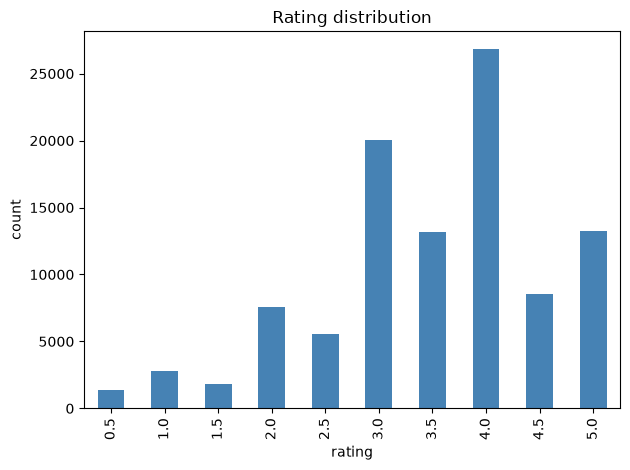

Mean rating: 3.502


In [4]:
ax = ratings.rating.value_counts().sort_index().plot.bar(color='steelblue')
ax.set_xlabel('rating'); ax.set_ylabel('count'); ax.set_title('Rating distribution')
plt.tight_layout(); plt.show()
print('Mean rating:', round(ratings.rating.mean(), 3))

Most ratings sit at 3–4 stars. A slight positivity bias that motivates **mean-centring** in collaborative filtering.

## The long tail

A handful of blockbusters collect most of the ratings; the vast majority of films are rated only a few times. A pure popularity recommender would only ever surface the head. The **tail is where personalisation and novelty live.**

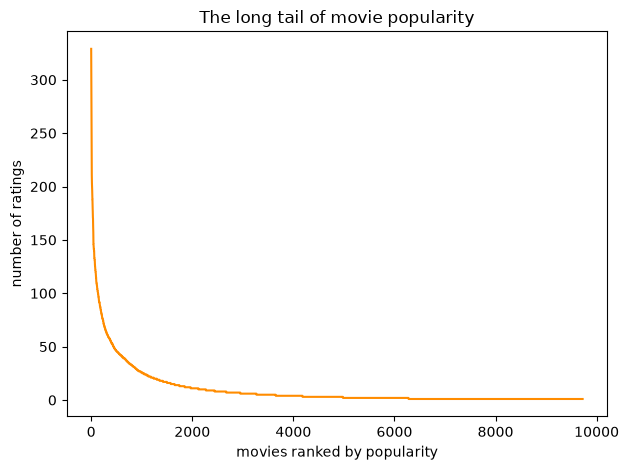

Half of all ratings go to just 658 movies (6.8% of the catalog).


In [5]:
counts = ratings.groupby('movieId').size().sort_values(ascending=False).values
plt.plot(range(len(counts)), counts, color='darkorange')
plt.xlabel('movies ranked by popularity'); plt.ylabel('number of ratings')
plt.title('The long tail of movie popularity'); plt.tight_layout(); plt.show()
top = int((counts.cumsum() <= 0.5 * counts.sum()).sum())
print(f'Half of all ratings go to just {top} movies ({top / len(counts):.1%} of the catalog).')

## How active are users / how rated are movies?

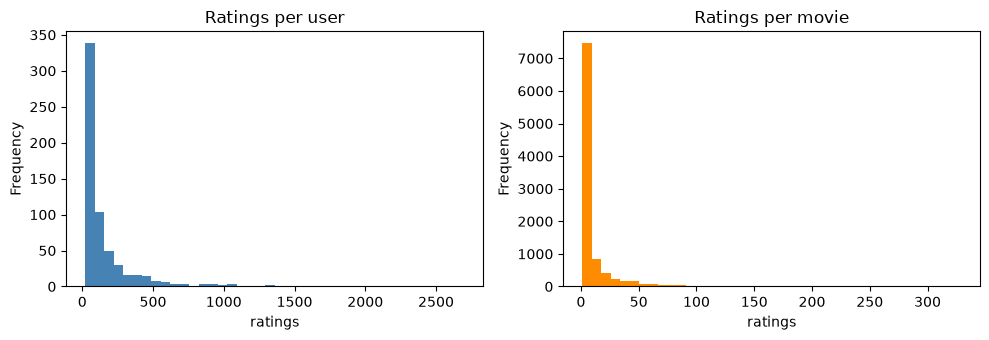

Median ratings/user: 70
Median ratings/movie: 3


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ratings.groupby('userId').size().plot.hist(bins=40, ax=ax[0], color='steelblue')
ax[0].set_title('Ratings per user'); ax[0].set_xlabel('ratings')
ratings.groupby('movieId').size().plot.hist(bins=40, ax=ax[1], color='darkorange')
ax[1].set_title('Ratings per movie'); ax[1].set_xlabel('ratings')
plt.tight_layout(); plt.show()
print('Median ratings/user:', int(ratings.groupby('userId').size().median()))
print('Median ratings/movie:', int(ratings.groupby('movieId').size().median()))

## Content features: genres and tags

These feed the **content-based** model (TF-IDF over the combined text).

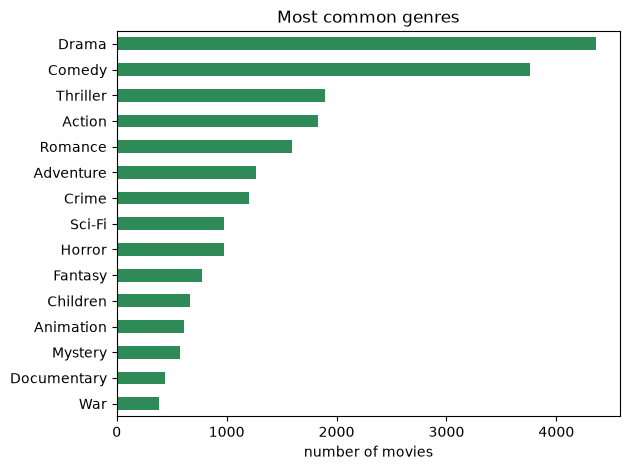

3,683 user tags, e.g.: ['funny', 'Highly quotable', 'will ferrell', 'Boxing story', 'MMA', 'Tom Hardy', 'drugs', 'Leonardo DiCaprio']


In [7]:
genres = movies.genres.str.get_dummies('|').sum().sort_values(ascending=False)
genres.head(15).plot.barh(color='seagreen').invert_yaxis()
plt.title('Most common genres'); plt.xlabel('number of movies')
plt.tight_layout(); plt.show()
print(f'{len(tags):,} user tags, e.g.:', list(tags.tag.head(8)))